In [70]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error
import seaborn as sns

<h1>Пока что попробуем самые простые модели: OLS & DecisionTreeRegressor</h1>

In [2]:
df = pd.read_parquet('./dataset/dataset.parquet')
df.head(4)

,Price,description,city,guests,bedrooms,beds,baths,luxury_items,s3_url
0,102699.0,Situated in one of Seattle's friendliest and f...,Seattle,10.0,5.0,5.0,3.5,0.0,http://localhost:9000/airbnb-images/image_1.jpg
1,208528.0,Midcentury modern 2bed/2bath stilt home with s...,Los Angeles,6.0,2.0,3.0,2.0,0.0,http://localhost:9000/airbnb-images/image_2.jpg
2,16264.0,Welcome to UNTITLED at 3 Freeman Alley!Our Stu...,New York,2.0,1.0,1.0,0.0,1.0,http://localhost:9000/airbnb-images/image_3.jpg
3,165885.0,Welcome to Piseco Lake House! Enjoy an authent...,Piseco,6.0,3.0,4.0,2.0,0.0,http://localhost:9000/airbnb-images/image_4.jpg


In [18]:
cr = df.iloc[:, [0, 3, 4, 5, 6, 7]].corr()

<Axes: >

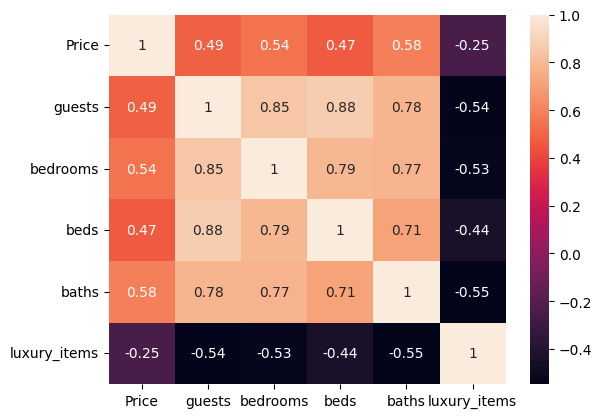

In [19]:
sns.heatmap(cr, annot=True)

<h3>Очевидная Мультиколлиреарность между Гостями и всем остальным.</h3>

In [28]:
model = LinearRegression()

s = SequentialFeatureSelector(
  model, 
  n_features_to_select= 4,
  scoring='r2',
  direction='forward',
  cv = 5,
  
)

s.fit(df.iloc[:, [3, 4, 5, 6, 7]], df['Price'])
ind = s.get_support(indices=True)
print(f'Sklearn feature selector: {s.get_support(indices=True)}')
(df.iloc[:, [3, 4, 5, 6, 7]]).iloc[:, ind]

Sklearn feature selector: [0 1 3 4]


,guests,bedrooms,baths,luxury_items
0,10.0,5.0,3.5,0.0
1,6.0,2.0,2.0,0.0
2,2.0,1.0,0.0,1.0
3,6.0,3.0,2.0,0.0
4,2.0,1.0,1.5,0.0
...,...,...,...,...
2106,8.0,4.0,2.0,0.0
2107,2.0,0.0,1.0,1.0
2108,6.0,1.0,1.0,0.0
2109,2.0,1.0,0.0,1.0


In [53]:
model = DecisionTreeRegressor(max_depth=4)

s = SequentialFeatureSelector(
  model, 
  n_features_to_select= 4,
  scoring='r2',
  direction='forward',
  cv = 5,
  
)

s.fit(df.iloc[:, [3, 4, 5, 6, 7]], df['Price'])
ind = s.get_support(indices=True)
print(f'Sklearn feature selector: {s.get_support(indices=True)}')
(df.iloc[:, [3, 4, 5, 6, 7]]).iloc[:, ind]

Sklearn feature selector: [1 2 3 4]


,bedrooms,beds,baths,luxury_items
0,5.0,5.0,3.5,0.0
1,2.0,3.0,2.0,0.0
2,1.0,1.0,0.0,1.0
3,3.0,4.0,2.0,0.0
4,1.0,1.0,1.5,0.0
...,...,...,...,...
2106,4.0,5.0,2.0,0.0
2107,0.0,1.0,1.0,1.0
2108,1.0,4.0,1.0,0.0
2109,1.0,1.0,0.0,1.0


<h1>Train-test Split</h1>

In [48]:
X_Linreg = df.iloc[:, [3, 4, 6, 7]]
Y = df['Price']
X_train_Linreg, X_test_Linreg, y_train_Linreg, y_test_Linreg = train_test_split(X_Linreg, Y, test_size=0.2)

In [49]:
X_tree = df.iloc[:, [4, 5, 6, 7]]
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, Y, test_size=0.2)

<h1>Hyperparameter Optimization</h1>

In [50]:
model = LinearRegression()

params = {'fit_intercept': [True, False]}

search = GridSearchCV(
  model,
  params
)

search.fit(X_train_Linreg, y_train_Linreg)

search.best_params_

{'fit_intercept': True}

In [51]:
model = DecisionTreeRegressor()

params = {'max_depth': [2, 3, 4, 5, 6, 7, 8]}

search = GridSearchCV(
  model,
  params
)

search.fit(X_train_tree, y_train_tree)

search.best_params_

{'max_depth': 5}

<h1>Feature Importance</h1>

In [63]:
model = DecisionTreeRegressor()

params = {'max_depth': [1, 2, 3, 4, 5, 6, 7, 8]}

search = GridSearchCV(
  model,
  params
)

search.fit(df.iloc[:, [3, 4, 5, 6, 7]], Y)

search.best_params_

{'max_depth': 2}

[Text(0.5, 0.8333333333333334, 'x[3] <= 1.25\nsquared_error = 7936412318.169\nsamples = 2111\nvalue = 109108.135'),
 Text(0.25, 0.5, 'x[1] <= 1.5\nsquared_error = 1575531488.13\nsamples = 1461\nvalue = 81076.777'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 1153448070.615\nsamples = 1184\nvalue = 75333.607'),
 Text(0.375, 0.16666666666666666, 'squared_error = 2636060682.072\nsamples = 277\nvalue = 105625.199'),
 Text(0.75, 0.5, 'x[3] <= 4.75\nsquared_error = 16497835571.992\nsamples = 650\nvalue = 172114.005'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 10422695083.612\nsamples = 635\nvalue = 162899.854'),
 Text(0.875, 0.16666666666666666, 'squared_error = 117933385640.729\nsamples = 15\nvalue = 562179.733')]

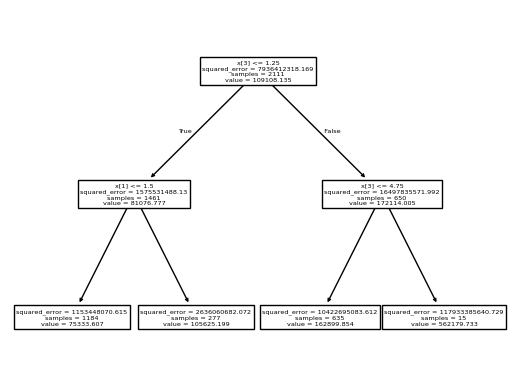

In [68]:
m1 = DecisionTreeRegressor(max_depth=2)
m1.fit(df.iloc[:, [3, 4, 5, 6, 7]], Y)
plot_tree(m1)

In [69]:
m1.score(df.iloc[:, [3, 4, 5, 6, 7]], Y)

0.37427303003582635

<h1>Estimation</h1>

In [74]:
model1 = LinearRegression()

model1.fit(X_train_Linreg, y_train_Linreg)
ypred = model1.predict(X_test_Linreg)
print(f'R-Squared: {model1.score(X_test_Linreg, y_test_Linreg)}')
print(f'MAE: {mean_absolute_error(y_test_Linreg, ypred)}')

R-Squared: 0.3490339347841588
MAE: 44301.616116793426


In [75]:
model2 = DecisionTreeRegressor(max_depth=4)

model2.fit(X_train_tree, y_train_tree)
ypred_1 = model2.predict(X_test_tree)
print(f'R-Squared: {model2.score(X_test_tree, y_test_tree)}')
print(f'MAE: {mean_absolute_error(y_test_tree, ypred_1)}')

R-Squared: 0.3406261722884423
MAE: 42112.61085346715
